<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); color: white; padding: 30px; border-radius: 15px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; text-align: center; box-shadow: 0 10px 20px rgba(0,0,0,0.19), 0 6px 6px rgba(0,0,0,0.23);">
    <div style="font-size: 50px; margin-bottom: 10px;"> 🤖</div>
    <h1 style="margin: 0; font-size: 36px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
        Tox21: Double Deep Q-Network
    </h1>
    <p style="font-size: 18px; margin-top: 5px; font-weight: 300;">
        Molecular decision-making with Double Deep Q-Networks
    </p>
    <p style="font-size: 16px; margin-top: 10px; font-weight: 300; line-height: 1.5;">
    The notebook is structured as follows: <br>
     <strong>Imports</strong> |  <strong>Dataset</strong> |  <strong>GNN Model</strong> |  <strong>Training</strong> |  <strong>Hyperparameter Search</strong> |  <strong>Test</strong>
</p>
</div>

# **Imports**

In [1]:
import torch
import os
import numpy as np
import random
from sklearn.model_selection import train_test_split
from rdkit import Chem, RDLogger
from src.DDQN.env import *
from src.DDQN.train import train_agent, DuelingDQN
from src.DDQN.evaluate import evaluate_model
from src.DGN.model import Tox21GNN
from src.DDQN.config import *
from src.DDQN.analysis import analysis
import pandas as pd
from src.DDQN.utils import set_seed
from src.DGN.config import MODEL_PATH as GNN_PATH
from src.DDQN.config import AGENT_PATH

set_seed(RANDOM_SEED)
RDLogger.DisableLog('rdApp.*') # disable rdkit warnings

# **Dataset**

In [2]:
# ---LOAD CUSTOM DATASET Tox21
tox21_df=pd.read_csv("datasets/tox21_processed_features.csv")
all_smiles=tox21_df["smiles"].values
print(f"DEBUG: Caricate {len(all_smiles)} righe dal CSV.")


train_smiles,temp_smiles = train_test_split(all_smiles, train_size=0.7, test_size=0.3, random_state=RANDOM_SEED)
valid_smiles, test_smiles = train_test_split(temp_smiles,test_size=0.5, random_state=RANDOM_SEED)

print(f"Totale molecole: {len(all_smiles)}")
print(f"Train Set (per RL Training): {len(train_smiles)} molecole")
print(f"Test Set (per Evaluation):   {len(test_smiles)} molecole")

DEBUG: Caricate 7823 righe dal CSV.
Totale molecole: 7823
Train Set (per RL Training): 5476 molecole
Test Set (per Evaluation):   1174 molecole


# **DGN** Predictor

In [9]:

print(f"- running on device: {DEVICE}")

print("- initializing GNN Predictor...")
gnn_model = Tox21GNN(num_node_features=NODE_FEATURES, 
                        hidden_channels=HIDDEN_CHANNELS, 
                        num_classes=NUM_CLASSES, 
                        dropout=DROPOUT,
                        num_global_features=NUM_GLOBAL_FEATURES)
gnn_model = gnn_model.to(DEVICE)

if os.path.exists(GNN_PATH):
    gnn_model.load_state_dict(torch.load(GNN_PATH, map_location=DEVICE))
    print(f"- uploaded DGN weights from {GNN_PATH}")
else:
    print(f"- DGN weights not found at {GNN_PATH}!")
    
_ = gnn_model.eval()


- running on device: cuda
- initializing GNN Predictor...
- uploaded DGN weights from weights/DGN/best_GNN.pth


# **Environment**

In [11]:

env = MoleculeEnv(gnn_model=gnn_model,
                  threshold=0.6,
                  max_steps=MAX_STEPS,
                  device=DEVICE,
                  w_tox=W_TOX,
                  w_flip=W_FLIP,
                  w_sim_penalty=W_PEN
)
print(f"- initialized Environment")


- initialized Environment


# **DDQN** Agent

In [13]:

policy_net = DuelingDQN(LATENT_DIM, env.action_space_size, hidden_dim=512)
target_net = DuelingDQN(LATENT_DIM, env.action_space_size, hidden_dim=512)
print("- initialized DDQN networks")


- initialized DDQN networks


# **Train**

In [ ]:

print(f"Starting Training for {EPOCHS_AGENT} episodes...")

"""
trained_agent = train_agent(
    p_model=policy_net,
    t_model=target_net,
    env,
    smiles_list=train_smiles, 
    batch_size=BATCH_SIZE_RL_AGENT, 
    lr=LR_GENERATOR,
    gamma=GAMMA
)


torch.save(trained_agent.state_dict(), AGENT_PATH)
print(f"Agent trained and saved to {AGENT_PATH}")

"""

Starting Training for 3000 episodes...


'\ntrained_agent = train_agent(\n    p_model=policy_net,\n    t_model=target_net,\n    env,\n    smiles_list=train_smiles, \n    batch_size=BATCH_SIZE_RL_AGENT, \n    lr=LR_GENERATOR,\n    gamma=GAMMA\n)\n'

# **Results**

Loading Best Agent from ./weights/DDQN/best_DDQN.pth for evaluation...

--- Evaluation (Multi-Task Flip & Similarity) | Attempts per mol: 10 ---

SUMMARY EVALUATION (1174 mols, 10 attempts/mol):
Strict Success Rate (Flip + Sim>=0.6):  27.26%
Loose Success Rate (Any Flip):          32.20%
------------------------------------------------------------
METRICHE SUI SUCCESSI (Counterfactuals Validi):
  > Avg Tanimoto (on Success):          0.675
  > Avg Hybrid Sim (on Success):        0.714
  > Avg Steps (on Success):             1.0
------------------------------------------------------------
Metriche Globali (inclusi fallimenti):
  > Avg Tanimoto (All):                 0.529

best_smiles found

CC(C)(CO)C(O)C(=O)NCCC(=O)NCCSSCCNC(=O)CCNC(=O)C(O)C(C)(C)CO+

CC(C)(CO)C(O)C(=O)NCCC(=O)NCCSSCCNC(=O)CCNC(=P)C(O)C(C)(C)CO+

CCC(C)(C)OC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CCSC)C(=O)N[C@@H](CC(=O)O)C(=O)N[C@@H](Cc1ccccc1)C(N)=O+

CCC(C)(C)OC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)N[C@@H](CCSC)C(=

c:\Users\Lorenzo\Desktop\RL_project\src\DDQN\analysis.py:405: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, y='Azione Rilevata', x='Count', palette='Set2', orient='h')


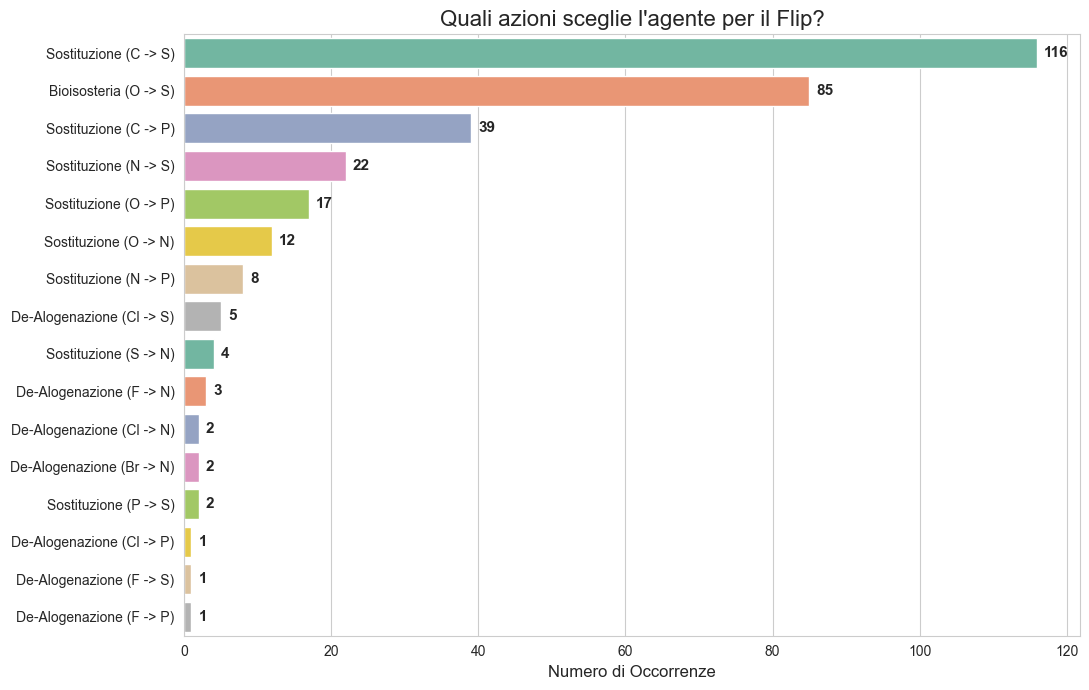

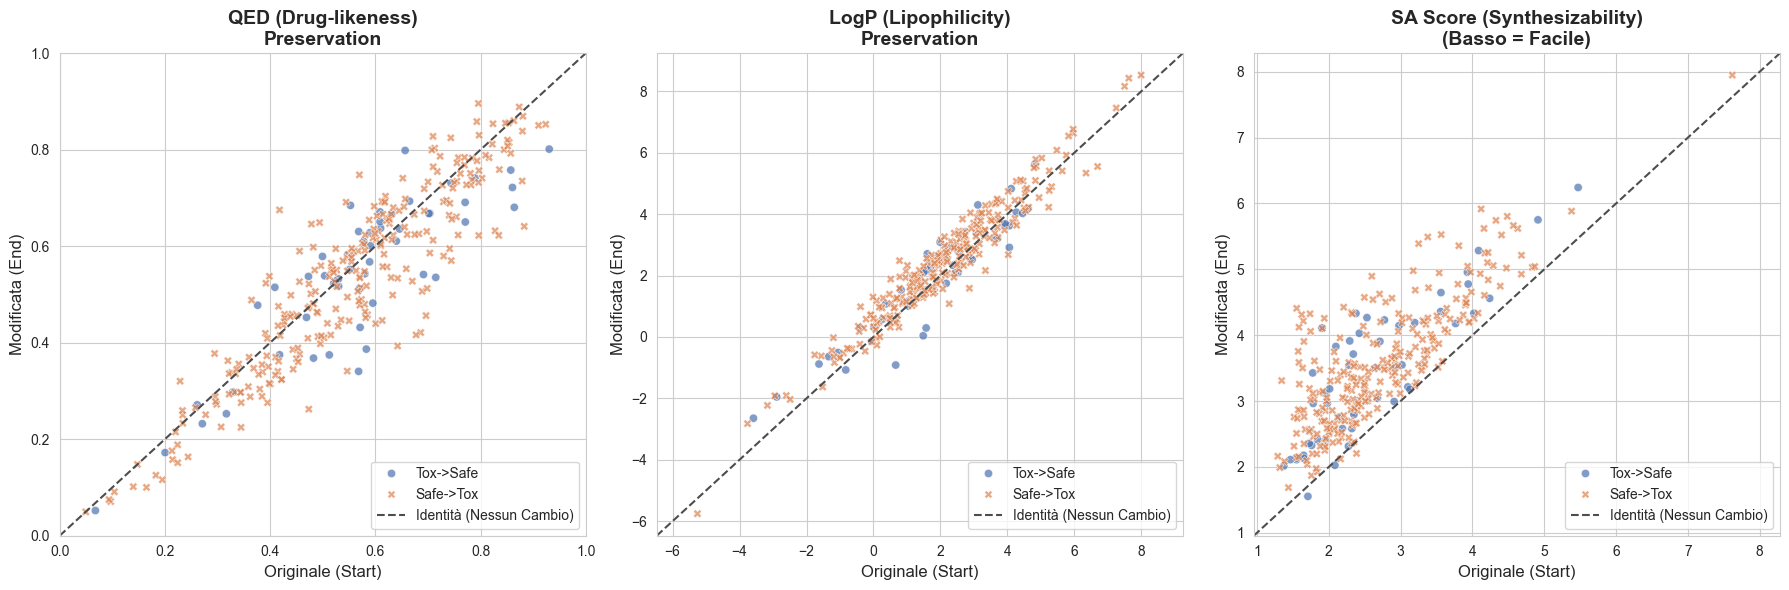


--- ANALISI PROPRIETÀ DRUG-LIKE ---
Totale transizioni analizzate: 320
Molecole con crollo QED (>0.1): 43 / 320 (13.4%)
Molecole diventate difficili da sintetizzare (Delta SA > 1.0): 100 (31.2%)


In [6]:

if os.path.exists(AGENT_PATH):
    print(f"Loading Best Agent from {AGENT_PATH} for evaluation...")
    best_agent = DuelingDQN(input_dim=LATENT_DIM, output_dim=env.action_space_size,hidden_dim=512).to(DEVICE)
    best_agent.load_state_dict(torch.load(AGENT_PATH))
    stats = evaluate_model(best_agent, env, test_smiles, device=DEVICE)
else:
    trained_agent = DuelingDQN(input_dim=LATENT_DIM, output_dim=env.action_space_size,hidden_dim=512).to(DEVICE)
    trained_agent.load_state_dict(torch.load(AGENT_PATH))

    stats=evaluate_model(trained_agent, env, test_smiles, device=DEVICE)
    

analysis(stats=stats)